In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("All imports loaded successfully")

Matplotlib is building the font cache; this may take a moment.


All imports loaded successfully


In [3]:
train_df = pd.read_csv("train.csv", header=None)
test_df = pd.read_csv("test.csv", header=None)

train_df.columns= ["label","title", "description"]
test_df.columns= ["label","title", "description"]

train_df["label"]=train_df["label"] - 1
test_df["label"]=test_df["label"] - 1

label_names= ["World", "Sports", "Business", "Sci/Tech"]

train_df["text"]=train_df["title"] + "" + train_df["description"]
test_df["text"]=test_df["title"]+ "" + train_df["description"]

train_df["category"]=train_df["label"].apply(lambda x: label_names[x])
test_df["category"]=test_df["label"].apply(lambda x: label_names[x])


print(train_df.shape)
print(test_df.shape)

train_df.head()

(120000, 5)
(7600, 5)


,label,title,description,text,category
0,2,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",Wall St. Bears Claw Back Into the Black (Reute...,Business
1,2,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,Carlyle Looks Toward Commercial Aerospace (Reu...,Business
2,2,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,Oil and Economy Cloud Stocks' Outlook (Reuters...,Business
3,2,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,Iraq Halts Oil Exports from Main Southern Pipe...,Business
4,2,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...","Oil prices soar to all-time record, posing new...",Business


In [ ]:
category_counts= train_df["category"].value_counts()
category_counts

category
Business    1900
Sci/Tech    1900
Sports      1900
World       1900
Name: count, dtype: int64

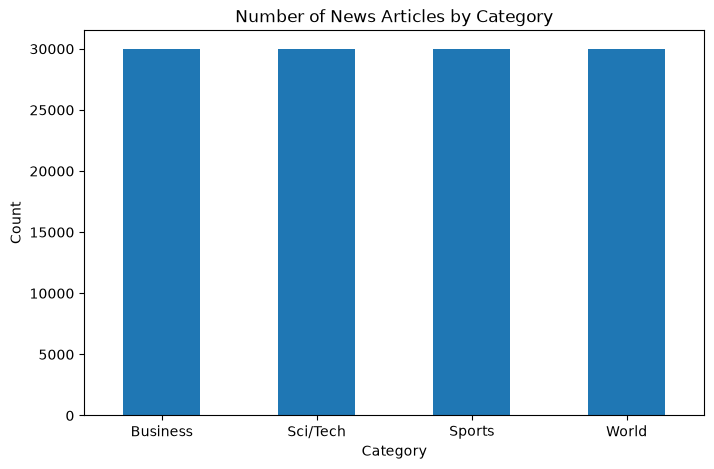

In [5]:
plt.figure(figsize=(8,5))
category_counts.plot(kind="bar")
plt.title("Number of News Articles by Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

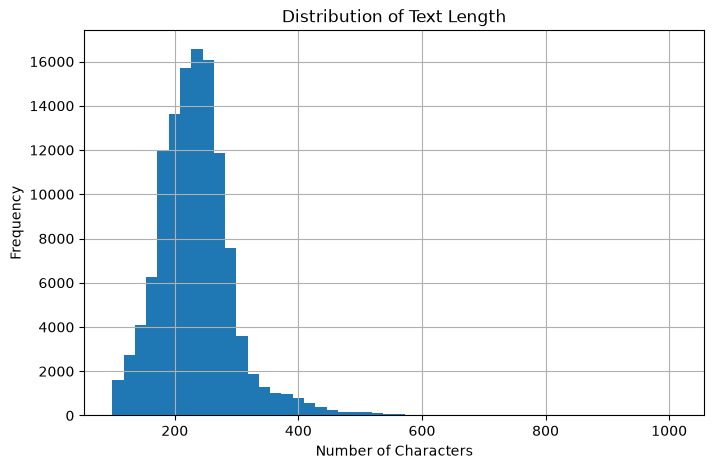

count    120000.000000
mean        235.477525
std          66.509741
min          99.000000
25%         195.000000
50%         231.000000
75%         265.000000
max        1011.000000
Name: text_length, dtype: float64

In [6]:
train_df["text_length"]= train_df["text"].apply(len)

plt.figure(figsize=(8,5))
train_df["text_length"].hist(bins=50)
plt.title("Distribution of Text Length")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.show()

train_df["text_length"].describe()

In [7]:
X_train = train_df["text"]
y_train = train_df["label"]

X_test = test_df["text"]
y_test = test_df["label"]

print("Number of training samples: ", len(X_train))
print("Number of testing samples: ", len(X_test))

Number of training samples:  120000
Number of testing samples:  7600


In [8]:
tfidf= TfidfVectorizer(
    max_features= 20000,
    stop_words= "english",
    ngram_range= (1,2)
)

X_train_tfidf= tfidf.fit_transform(X_train)
X_test_tfidf= tfidf.transform(X_test)

print("TF_IDF training matrix shape:", X_train_tfidf.shape)
print("TF_IDF testing matrix shape:", X_test_tfidf.shape)

TF_IDF training matrix shape: (120000, 20000)
TF_IDF testing matrix shape: (7600, 20000)


In [9]:
print("LogisticRegression loaded successfully")

tfidf_model= LogisticRegression(max_iter=1000)
tfidf_model.fit(X_train_tfidf, y_train)

y_pred_tfidf = tfidf_model.predict(X_test_tfidf)

tfidf_accuracy = accuracy_score(y_test, y_pred_tfidf)

print("TF-IDF Model Accuracy:", round(tfidf_accuracy, 4))
print()
print(classification_report(y_test, y_pred_tfidf, target_names= label_names))


LogisticRegression loaded successfully
TF-IDF Model Accuracy: 0.3212

              precision    recall  f1-score   support

       World       0.34      0.34      0.34      1900
      Sports       0.29      0.29      0.29      1900
    Business       0.32      0.32      0.32      1900
    Sci/Tech       0.34      0.33      0.34      1900

    accuracy                           0.32      7600
   macro avg       0.32      0.32      0.32      7600
weighted avg       0.32      0.32      0.32      7600



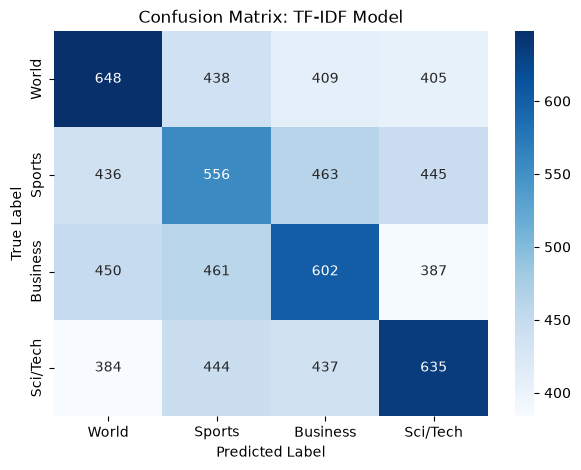

In [10]:
cm_tfidf = confusion_matrix(y_test, y_pred_tfidf)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_tfidf,
    annot=True,
    fmt="d",
    xticklabels=label_names,
    yticklabels=label_names,
    cmap="Blues"
)
plt.title("Confusion Matrix: TF-IDF Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

1)The category with the highest accuracy is the 'World' Category.
2) The categories that are most often confused seem to be Sports and Business
3) Business and Sci/Tech may sometimes overlap as articles may be talking about Sci/Tech companies for business. E.g) A company that is science and technology such as SpaceX doing an IPO.
4) A manager would probably need more detailed business categories as they seem to be confused pretty often. Additionally, some articles may belong into multiple categories at the same time.

In [12]:
from huggingface_hub import snapshot_download
import tqdm

snapshot_download(
    repo_id= "sentence-transformers/all-MiniLM-L6-v2",
    local_dir="./models/all-MiniLM-L6-v2",
    local_dir_use_symlinks=False
)

c:\Users\robin\Downloads\LLM_project_1\venvLLM\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\robin\Downloads\LLM_project_1\venvLLM\Lib\site-packages\huggingface_hub\utils\_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Fetching 30 files: 100%|██████████| 30/30 [02:58<00:00,  5.95s/it]


'C:\\Users\\robin\\Downloads\\LLM_project_1\\models\\all-MiniLM-L6-v2'

In [13]:
from sentence_transformers import SentenceTransformer
embedding_model= SentenceTransformer("all-MiniLM-L6-v2")

c:\Users\robin\Downloads\LLM_project_1\venvLLM\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\robin\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4408.61it/s]


In [14]:
train_sample= train_df.sample(10000,random_state=42)
test_sample= test_df.sample(2000,random_state=42)

X_train_sample= train_sample["text"].tolist()
y_train_sample= train_sample["label"].values

X_test_sample= test_sample["text"].tolist()
y_test_sample= test_sample["label"].values

print("Training sample size:", len(X_train_sample))
print("Testing sample size:", len(X_test_sample))

Training sample size: 10000
Testing sample size: 2000


In [15]:
X_train_emb = embedding_model.encode(
    X_train_sample,
    show_progress_bar=True,
    batch_size=64
)

X_test_emb = embedding_model.encode(
    X_test_sample,
    show_progress_bar=True,
    batch_size=64
)

print("Training embedding shape:", X_train_emb.shape)
print("Testing embedding shape:", X_test_emb.shape)

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Batches: 100%|██████████| 32/32 [00:30<00:00,  1.05it/s]

Training embedding shape: (10000, 384)
Testing embedding shape: (2000, 384)


In [16]:
embedding_classifier= LogisticRegression(max_iter=1000)
embedding_classifier.fit(X_train_emb, y_train_sample)

y_pred_emb= embedding_classifier.predict(X_test_emb)
embedding_accuracy= accuracy_score(y_test_sample, y_pred_emb)

print("Transformer Embedding Model Accuracy:", round(embedding_accuracy, 4))
print()
print(classification_report(y_test_sample, y_pred_emb, target_names=label_names))

Transformer Embedding Model Accuracy: 0.4245

              precision    recall  f1-score   support

       World       0.45      0.46      0.46       493
      Sports       0.39      0.38      0.39       504
    Business       0.41      0.40      0.40       474
    Sci/Tech       0.45      0.45      0.45       529

    accuracy                           0.42      2000
   macro avg       0.42      0.42      0.42      2000
weighted avg       0.42      0.42      0.42      2000



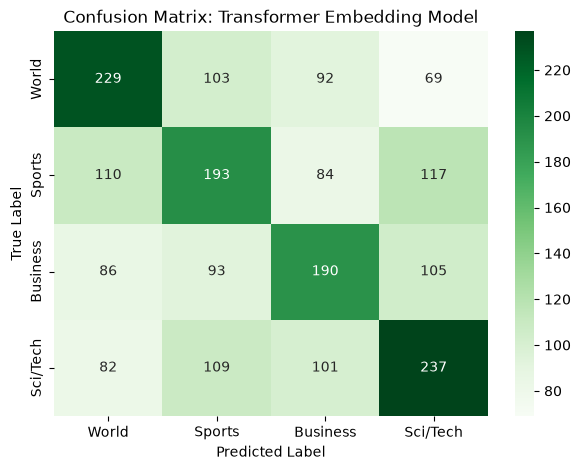

In [17]:
cm_emb = confusion_matrix(y_test_sample, y_pred_emb)

plt.figure(figsize=(7,5))
sns.heatmap(
    cm_emb,
    annot=True,
    fmt="d",
    xticklabels=label_names,
    yticklabels=label_names,
    cmap="Greens"
)
plt.title("Confusion Matrix: Transformer Embedding Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [18]:
results= pd.DataFrame({
    "Model": ["TF-IDF + Logistic Regression",
              "SentenceTransformer + Logistic Regression"
              ],
    "Accuracy": [
        tfidf_accuracy,
        embedding_accuracy
        ]
})

results

,Model,Accuracy
0,TF-IDF + Logistic Regression,0.321184
1,SentenceTransformer + Logistic Regression,0.424500


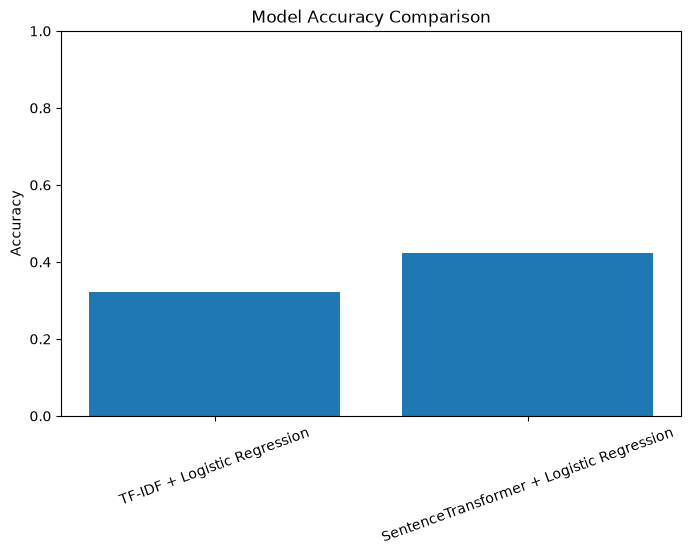

In [19]:
plt.figure(figsize=(8,5))
plt.bar(results["Model"],results["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.xticks(rotation=20)
plt.show()

# Come back to this part, we include the code of the teacher, but may require a bit more look into

In [20]:
tfidf_sample= TfidfVectorizer(
    max_features=20000,
    stop_words="english",
    ngram_range=(1,2)
)

X_train_sample_tfidf= tfidf_sample.fit_transform(train_sample["text"])
X_test_sample_tfidf= tfidf_sample.transform(test_sample["text"])

tfidf_sample_model= LogisticRegression(max_iter=1000)
tfidf_sample_model.fit(X_train_sample_tfidf, y_train_sample)

y_pred_tfidf_sample= tfidf_sample_model.predict(X_test_sample_tfidf)

tfidf_sample_accuracy = accuracy_score(y_test_sample, y_pred_tfidf_sample)

fair_results= pd.DataFrame({
    "Model": [
        "TF-IDF sample model",
        "Transformer embedding sample model"
    ],
    "Accuracy": [
        tfidf_sample_accuracy,
        embedding_accuracy
    ]
})

fair_results

,Model,Accuracy
0,TF-IDF sample model,0.3260
1,Transformer embedding sample model,0.4245


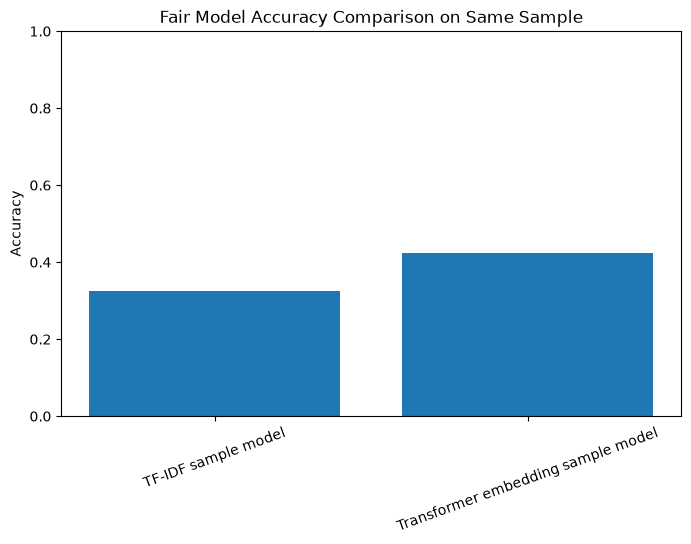

In [21]:
plt.figure(figsize=(8,5))
plt.bar(fair_results["Model"],fair_results["Accuracy"])
plt.title("Fair Model Accuracy Comparison on Same Sample")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.xticks(rotation=20)
plt.show()

In [22]:
new_headlines=[
    "Apple shares rise after strong iPhone sales in China",
    "Oil prices fall as middle East tensions rise",
    "New AI chip startup raises 500 million dollars",
    "Central bank signals possible interest rate cuts",
    "Football club signs record broadcasting deal"
]


new_embeddings= embedding_model.encode(new_headlines)
new_predictions= embedding_classifier.predict(new_embeddings)

for headline, pred in zip(new_headlines, new_predictions):
  print("Headline:", headline)
  print("Predicted category:", label_names[pred])
  print()

Headline: Apple shares rise after strong iPhone sales in China
Predicted category: Business

Headline: Oil prices fall as middle East tensions rise
Predicted category: Business

Headline: New AI chip startup raises 500 million dollars
Predicted category: Business

Headline: Central bank signals possible interest rate cuts
Predicted category: Business

Headline: Football club signs record broadcasting deal
Predicted category: Sports



# Now need to add here the new Headlines + Discuss

Additional Headlines added

In [23]:
new_headlines=[
    " SpaceX raised $75B in record IPO – here’s why insiders like Elon Musk are much likelier than public stock buyers to get rocket-powered returns these days",
    "Oil prices fall and shares jump after US-Iran deal announced",
    "Bay FC Acquires Forward Keira Barry via Transfer with Manchester United",
    "Yen Short Bets Jump to Nine-Year High as Carry Trade Revives",
    "Bezos says the only thing holding back data centers in space is cost, not science",
    "Tesco Sales Hit By Wet Weather and Weaker Spending",
    "Russia Piles Up Debt as Costs of War in Ukraine Outrun Budget",
    "EU Green Bond Regulation: end of transitional regime for external reviewers",
    "Investors brace for less predictable Fed as Warsh rewrites playbook",
    "The Hidden Cost of the Most Expensive World Cup Ever"
]

new_embeddings= embedding_model.encode(new_headlines)
new_predictions= embedding_classifier.predict(new_embeddings)

for headline, pred in zip(new_headlines, new_predictions):
  print("Headline:", headline)
  print("Predicted category:", label_names[pred])
  print()

Headline:  SpaceX raised $75B in record IPO – here’s why insiders like Elon Musk are much likelier than public stock buyers to get rocket-powered returns these days
Predicted category: Business

Headline: Oil prices fall and shares jump after US-Iran deal announced
Predicted category: Business

Headline: Bay FC Acquires Forward Keira Barry via Transfer with Manchester United
Predicted category: Sports

Headline: Yen Short Bets Jump to Nine-Year High as Carry Trade Revives
Predicted category: Business

Headline: Bezos says the only thing holding back data centers in space is cost, not science
Predicted category: Sci/Tech

Headline: Tesco Sales Hit By Wet Weather and Weaker Spending
Predicted category: Business

Headline: Russia Piles Up Debt as Costs of War in Ukraine Outrun Budget
Predicted category: World

Headline: EU Green Bond Regulation: end of transitional regime for external reviewers
Predicted category: Business

Headline: Investors brace for less predictable Fed as Warsh rewri

Small review of those additional 10 headlines:
1) This is correctly mentioned as Business even though some keywords such as rockets and Space are included.
2)The oil prices jumping headline is defined as Business. While this is technically correct, it may also be considered as 'World'. This is due to the headline really belonging to both labels.
3)Again, for the Bay FC headline, this is debatable. While the headline is clearly talking about sports, it is about the acquisition of a player. Therefore it may also be considered as Business.
4) The model correctly classifies this as Business.
5) Interestingly here, the actual headline is probably closer to Business than Sci/Tech. Although the headline is talking about a tech company, it is talking about the costs of data centers, and therefore closer to business.
6) Again here, this is correctly classified as business, even though the weather is mentioned.
7) While this headline is talking about business and economics, it is clear that it is talking about geopolitics. Therefore, I would argue that this is correctly classified as World.
8)Correctly classified as Business
9)Interestingly, here the model correctly classifies this as Business, even though no keywords are mentioned apart from 'Fed' and 'Investors'.
10) Here, we find that the model again incorrectly classified a headline as 'Sports' when it would be more accurate to be classified as 'Business'. This is probably due to the World Cup being mentioned.

In [24]:
error_df= test_sample.copy()
error_df["predicted_label"]= y_pred_emb
error_df["predicted_category"]= error_df["predicted_label"].apply(lambda x: label_names[x])
error_df["correct_category"]=error_df["label"].apply(lambda x: label_names[x])
error_df["is_correct"]= error_df["label"]==error_df["predicted_label"]

mistakes= error_df[error_df["is_correct"]==False]

print("Number of mistakes: ", len(mistakes))
mistakes[["text", "correct_category","predicted_category"]].head(20)

Number of mistakes:  1151


,text,correct_category,predicted_category
1017,Paris Tourists Search for Key to 'Da Vinci Cod...,World,Business
2850,"Net firms: Don't tax VoIPIn a report, it says ...",Sci/Tech,Business
457,EDS Is Charter Member of Siebel BPO Alliance (...,Sci/Tech,Sports
6256,Campbell 9 Pct. Profit #39;Hmmm Hmmm Good #39...,Business,Sports
2941,Salvaging GenesisFive Palestinians were killed...,Sci/Tech,World
408,Chavez rejects CD as oppositionOnline search e...,Business,Sci/Tech
773,NCAA Wrong To Close Book On WilliamsPCS Vision...,Sports,Sci/Tech
2836,General Mills goes whole grainsAug. 18 (Bloomb...,Business,World
7303,"Big merger could box Qwest inAt first glance, ...",Business,Sci/Tech
6770,Ukrainian opposition makes gainsIn one of the ...,World,Sci/Tech


1) We would argue here that the model is not clearly wrong in most cases. For example, the first headline indicated here may well be related to business as well.
However, in other cases e.g. the last headline inputted here seems to be completely wrong. In the headline nothing is inputted about Sports, however that becomes the predicted category, probably as the result of NBC being included.

2) The headlines can be quite ambiguous. From looking at the first article, it is unclear the reason why it mentions Paris tourists for example, which end up confusing the model. Additionally, we can see from the 19th headline that the initial phrase(different time, different team) seems to have no relation to the rest of the headline, and thus leading to the wrong predictions.

3) As mentioned before, the articles could clearly be included into more than category in certain cases. In other cases however, it is simply more specialised categories that may be required.

4) As mentioned in 3, this is probably the case. For example the last of the headlines here would probably more belong to a 'reality show' category, which however is not included here. Therefore, the model needs to decide between two categories which are not entirely applicable.

5) From those answers and predictions, it is here that a business user would probably need a more specialised category system which may define more specialised categories instead of simply 'business'. Additionally, a business user may require a category system that allows for multiple categories.

In [25]:
mistakes[["text", "correct_category","predicted_category"]].sample(
    min(10, len(mistakes)),
    random_state=0
)

,text,correct_category,predicted_category
2796,"For Neglected Video, a Hollywood TouchMARK Lat...",Sci/Tech,World
7380,No. 1 LSU overcomes stubborn host MinnesotaMUM...,Sports,Business
3071,This year #39;s Panthers could learn a thing o...,Sports,World
6650,Princess Di's Ex-Bodyguard Disputes Claim (AP)...,World,Sports
5974,Kashmiris reject Indian PM #39;s offerATHENS: ...,World,Sports
408,Chavez rejects CD as oppositionOnline search e...,Business,Sci/Tech
2252,Bloglines aims for simplicity (SiliconValley.c...,Sci/Tech,Sports
4987,Singapore Shares End Up on Wall St. GainsIsrae...,Business,World
6138,Lawyers In the LimelightAFP - South Africa com...,Business,Sports
1025,Crude oil prices soar on drop in US oil invent...,Business,World


In [26]:
feature_names= np.array(tfidf.get_feature_names_out())

for class_index, class_name in enumerate(label_names):
  top_indices= tfidf_model.coef_[class_index].argsort()[-15:][::-1]
  top_words = feature_names[top_indices]

  print("Class: ", class_name)
  print("Top words: ", ", ".join(top_words))
  print()

Class:  World
Top words:  afp, iraq, iraqi, canadian press, nuclear, york, afp afp, york stocks, palestinian, military, iran, arafat, president, troops, hostage

Class:  Sports
Top words:  coach, cup, team, sports, league, season, stadium, olympic, players, nba, teams, nascar, baseball, quarterback, night

Class:  Business
Top words:  economy, oil, hellip, bank, company, airlines, economic, tax, corp, insurance, retailers, dollar, business, amp, enron

Class:  Sci/Tech
Top words:  space, internet, software, nasa, scientists, reuters reuters, apple, web, microsoft, technology, linux, online, study, computer, science



# Explain What we can see here

Streamlit App

In [27]:
! pip install streamlit

  Using cached pyarrow-24.0.0-cp312-cp312-win_amd64.whl.metadata (3.0 kB)
  Using cached websockets-16.0-cp312-cp312-win_amd64.whl.metadata (7.0 kB)
     ---------------------------------------- 0.0/44.3 kB ? eta -:--:--
     ---------------------------------------- 0.0/44.3 kB ? eta -:--:--
     ------------------ --------------------- 20.5/44.3 kB ? eta -:--:--
     ------------------ --------------------- 20.5/44.3 kB ? eta -:--:--
     ------------------ --------------------- 20.5/44.3 kB ? eta -:--:--
     ----------------------------------- -- 41.0/44.3 kB 196.9 kB/s eta 0:00:01
     -------------------------------------- 44.3/44.3 kB 182.1 kB/s eta 0:00:00
  Using cached jsonschema-4.26.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached charset_normalizer-3.4.7-cp312-cp312-win_amd64.whl.metadata (41 kB)
  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached referencing-0.


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import joblib

joblib.dump(embedding_classifier, "embedding_classifier.joblib")
train_df.to_csv("Train DF.csv")

['embedding_classifier.joblib']